1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step


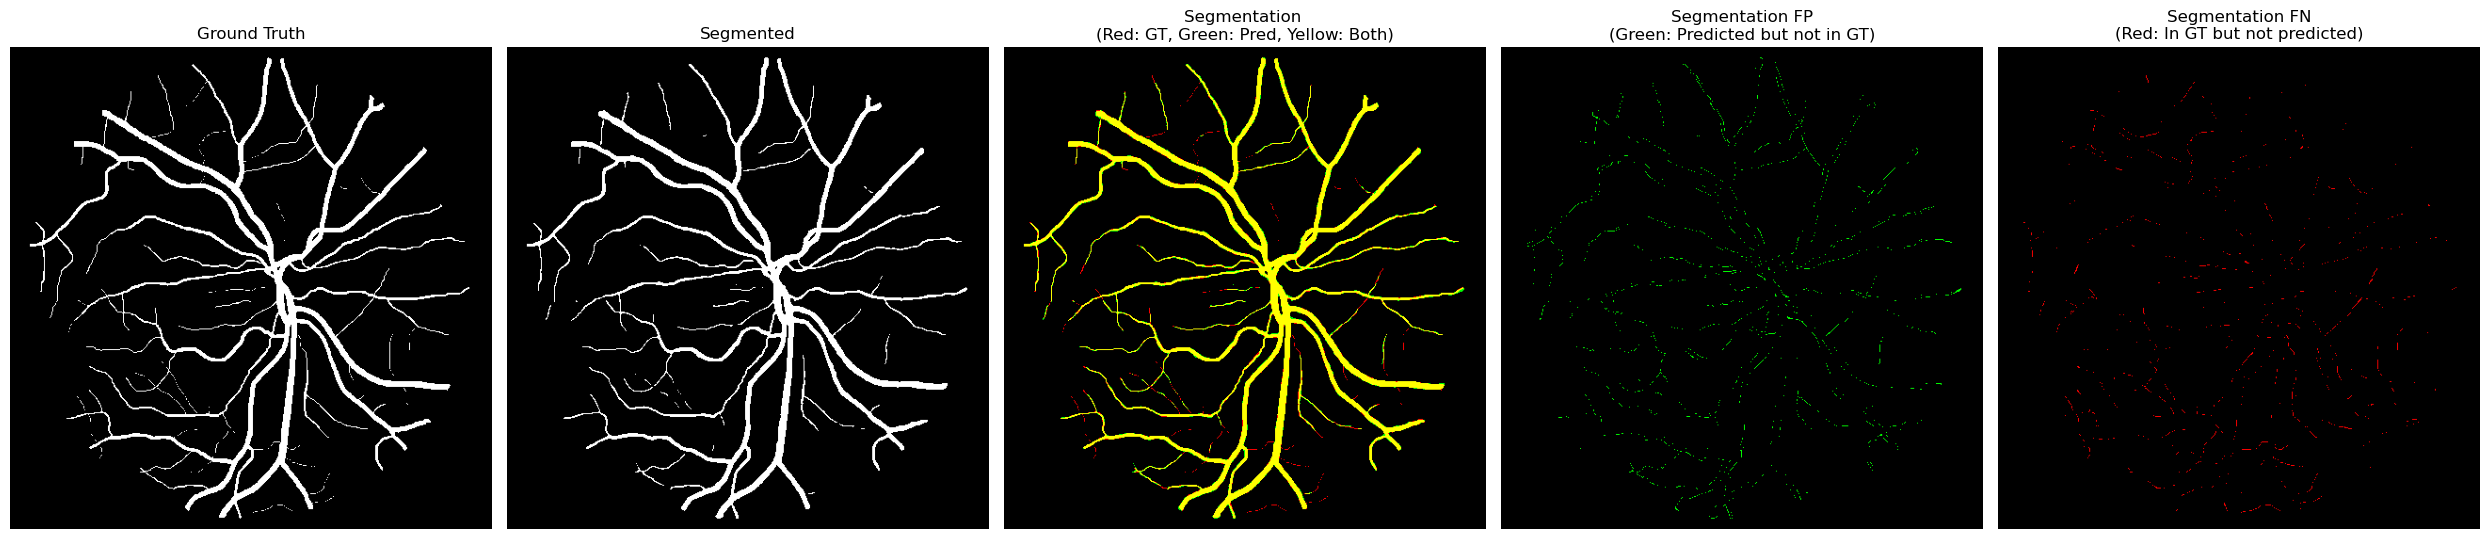

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load your model
model = load_model(r"E:\ASI\ASI_Retinal_ChaseGT1.h5", compile=False)

def getPrediction(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, 0)[:,:,:,0:3]
    mask= model.predict(img)
    return mask

# Load and prepare images
img_path = r"E:\ASI\CHASE DB1\Chase\Test\Images\Image_02R.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))

# Load ground truth masks
mask = cv2.imread(r"E:\ASI\CHASE DB1\Chase\Test\GT1\Image_02R_1stHO.png", cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (512, 512))
_, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
# Get predictions
msk= getPrediction(img_path, model)
mask_pred = (msk[0,:,:,0] > 0.1).astype(np.uint8)
# Create the visualization
plt.figure(figsize=(25, 12))

# ICM Ground Truth (Grayscale)
plt.subplot(1, 5, 1)
plt.imshow(mask, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')
# ICM Predicted (Grayscale)
plt.subplot(1, 5, 2)
plt.imshow(mask_pred, cmap='gray')
plt.title('Segmented')
plt.axis('off')
# Combined ICM
plt.subplot(1, 5, 3)
combined_mask = np.zeros((*mask_pred.shape, 3))
gt_mask = mask.astype(bool)
pred_mask = mask_pred.astype(bool)
combined_mask[gt_mask, 0] = 1  # Red for ground truth
combined_mask[pred_mask, 1] = 1  # Green for predicted
combined_mask[gt_mask & pred_mask, :2] = 1  # Yellow for overlap
plt.imshow(combined_mask)
plt.title('Segmentation \n(Red: GT, Green: Pred, Yellow: Both)')
plt.axis('off')
# ICM False Positives (Predicted but not in GT)
plt.subplot(1, 5, 4)
fp_mask = np.zeros_like(combined_mask)
fp_mask[pred_mask & ~gt_mask, 1] = 1  # Green for false positives
plt.imshow(img)
plt.imshow(fp_mask, alpha=1)
plt.title('Segmentation FP\n(Green: Predicted but not in GT)')
plt.axis('off')
# ICM False Negatives (In GT but not predicted)
plt.subplot(1, 5, 5)
fn_mask = np.zeros_like(combined_mask)
fn_mask[gt_mask & ~pred_mask, 0] = 1  # Red for false negatives
plt.imshow(img)
plt.imshow(fn_mask, alpha=1)
plt.title('Segmentation FN\n(Red: In GT but not predicted)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.20.0
3.10.0


Pixel Flipping

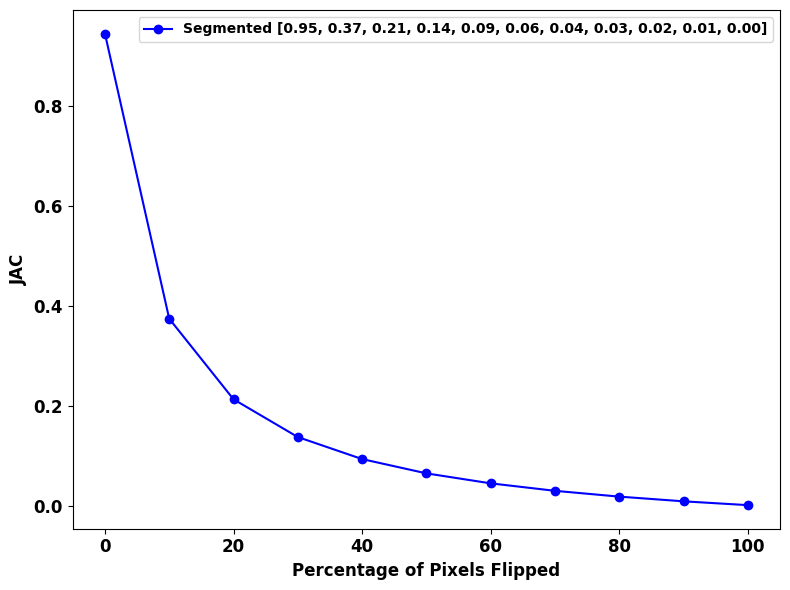

In [3]:
def calculate_iou(true_mask, predicted_mask):
    intersection = np.logical_and(true_mask, predicted_mask).sum()
    union = np.logical_or(true_mask, predicted_mask).sum()
    return intersection / (union + 1e-6)

def pixel_flipping_map(true_mask, predicted_mask, steps=10):
    height, width = true_mask.shape
    flipped_map = np.zeros((height, width))
    iou_scores = []
    pixel_steps = []
    total_pixels = height * width
    pixel_indices = np.random.permutation(total_pixels)
    flipped_mask = predicted_mask.copy()
    
    for i, idx in enumerate(pixel_indices):
        x, y = divmod(idx, width)
        flipped_mask[x, y] = 1 - flipped_mask[x, y]
        if i % (total_pixels // steps) == 0:
            iou = calculate_iou(true_mask, flipped_mask)
            iou_scores.append(iou)
            pixel_steps.append((i / total_pixels) * 100)
            flipped_map[x, y] = iou
            
    return flipped_map, iou_scores, pixel_steps

def plot_iou_degradation(mask_data):
    # Create figure for IoU degradation plot
    plt.figure(figsize=(8, 6))
    
    # Colors for different mask types
    colors = {'Segmented': 'b'}
    
    # Plot IoU degradation for each mask type
    for mask_type, true_mask, pred_mask in mask_data:
        # Calculate pixel flipping results
        _, iou_degradation, pixel_steps = pixel_flipping_map(true_mask, pred_mask)
        
        # Format IoU scores for legend
        iou_label = f"{mask_type} [{', '.join([f'{x:.2f}' for x in iou_degradation])}]"
        # Plot IoU degradation with custom legend label
        plt.plot(pixel_steps, iou_degradation, marker='o', linestyle='-', color=colors[mask_type], label=iou_label)
    
    # Finalize IoU Degradation Plot
    plt.xlabel("Percentage of Pixels Flipped", fontsize=12, fontweight='bold')
    plt.ylabel("JAC", fontsize=12, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(fontsize=8, prop={'weight': 'bold'})
    
    plt.tight_layout()
    plt.show()

# Process the mask for IoU degradation
mask_data = []
mask_type = 'Segmented'
true_mask_binary = mask  # Already binary
pred_mask = mask_pred  # Already binary
mask_data.append((mask_type, true_mask_binary, pred_mask))

# Plot only IoU degradation
plot_iou_degradation(mask_data)

Pixel flipping on overall image

Processing 3 images for average pixel flipping...


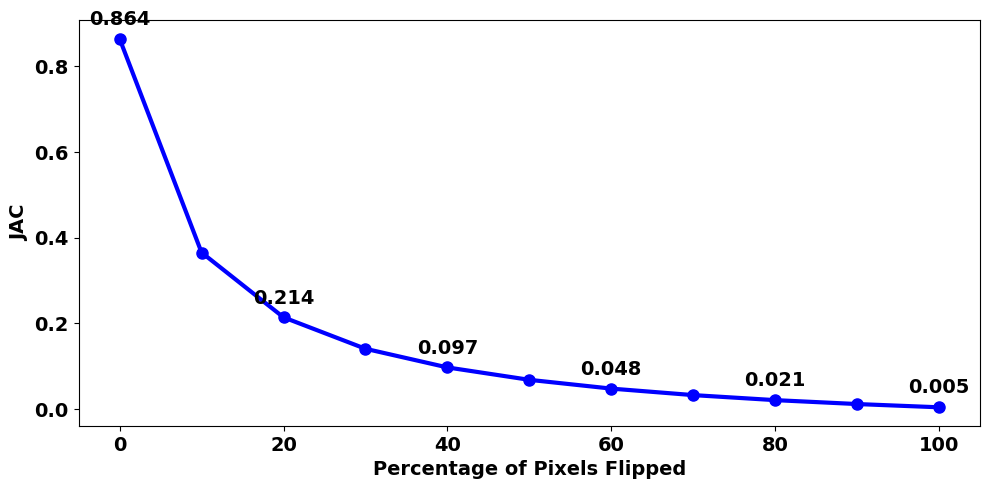


AVERAGE PIXEL FLIPPING EVALUATION RESULTS

Initial IoU Statistics (across 3 images):
  Average Initial IoU: 0.8639 ± 0.0108
  Range: [0.8489, 0.8742]

Average IoU Degradation after Pixel Flipping:
  0% pixels flipped: IoU = 0.8638
  10% pixels flipped: IoU = 0.3655
  20% pixels flipped: IoU = 0.2143
  30% pixels flipped: IoU = 0.1410
  40% pixels flipped: IoU = 0.0975
  50% pixels flipped: IoU = 0.0686
  60% pixels flipped: IoU = 0.0481
  70% pixels flipped: IoU = 0.0330
  80% pixels flipped: IoU = 0.0212
  90% pixels flipped: IoU = 0.0121
  100% pixels flipped: IoU = 0.0045

Key Metrics:
  Initial IoU (0% flipped): 0.8638
  Final IoU (100% flipped): 0.0045
  Absolute degradation: 0.8593
  Relative degradation: 99.48%


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# Load your model
model = load_model(r"E:\ASI\ASI_Retinal_ChaseGT1.h5", compile=False)

def getPrediction(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, 0)[:,:,:,0:3]
    mask = model.predict(img, verbose=0)
    return mask

def calculate_iou(true_mask, predicted_mask):
    intersection = np.logical_and(true_mask, predicted_mask).sum()
    union = np.logical_or(true_mask, predicted_mask).sum()
    return intersection / (union + 1e-6)

def pixel_flipping_map(true_mask, predicted_mask, steps=10):
    height, width = true_mask.shape
    iou_scores = []
    pixel_steps = []
    total_pixels = height * width
    pixel_indices = np.random.permutation(total_pixels)
    flipped_mask = predicted_mask.copy()
    
    for i, idx in enumerate(pixel_indices):
        x, y = divmod(idx, width)
        flipped_mask[x, y] = 1 - flipped_mask[x, y]
        if i % (total_pixels // steps) == 0:
            iou = calculate_iou(true_mask, flipped_mask)
            iou_scores.append(iou)
            pixel_steps.append((i / total_pixels) * 100)
            
    return iou_scores, pixel_steps

def calculate_average_pixel_flipping(pimages_path, ground_truth_path, steps=10):
    # Get all image files
    image_files = [f for f in os.listdir(pimages_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    
    all_iou_scores = []
    initial_ious = []
    
    print(f"Processing {len(image_files)} images for average pixel flipping...")
    
    for image_file in image_files:
        try:
            # Construct paths
            img_path = os.path.join(pimages_path, image_file)
            base_name = os.path.splitext(image_file)[0]
            mask_name = f"{base_name}_1stHO.png"
            gt_path = os.path.join(ground_truth_path, mask_name)
            
            # Check if ground truth exists
            if not os.path.exists(gt_path):
                print(f"Warning: Ground truth not found for {image_file}")
                continue
            
            # Load ground truth mask
            mask_gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
            mask_gt = cv2.resize(mask_gt, (512, 512))
            _, mask_gt = cv2.threshold(mask_gt, 127, 1, cv2.THRESH_BINARY)
            
            # Get prediction
            msk = getPrediction(img_path, model)
            mask_pred = (msk[0,:,:,0] > 0.1).astype(np.uint8)
            
            # Calculate initial IoU
            initial_iou = calculate_iou(mask_gt, mask_pred)
            initial_ious.append(initial_iou)
            
            # Perform pixel flipping
            iou_scores, pixel_steps = pixel_flipping_map(mask_gt, mask_pred, steps)
            all_iou_scores.append(iou_scores)
            
        except Exception as e:
            print(f"Error processing {image_file}: {str(e)}")
            continue
    
    # Calculate average IoU scores across all images
    if all_iou_scores:
        avg_iou_scores = np.mean(all_iou_scores, axis=0)
        return avg_iou_scores, pixel_steps, initial_ious
    else:
        return None, None, None

def plot_average_iou_degradation(avg_iou_scores, pixel_steps):
    # Create figure for average IoU degradation plot
    plt.figure(figsize=(10, 5))
    
    # Plot average IoU degradation
    plt.plot(pixel_steps, avg_iou_scores, marker='o', linestyle='-', linewidth=3, 
             color='blue', markersize=8)
    
    # Finalize IoU Degradation Plot
    plt.xlabel("Percentage of Pixels Flipped", fontsize=14, fontweight='bold')
    plt.ylabel("JAC", fontsize=14, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    #plt.title('Average Pixel Flipping Analysis - IoU Degradation', fontsize=14, fontweight='bold')
    
    # Add IoU values on the plot
    for i, (x, y) in enumerate(zip(pixel_steps, avg_iou_scores)):
        if i % 2 == 0:  # Show every other value to avoid clutter
            plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                        xytext=(0,10), ha='center', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def print_average_statistics(initial_ious, avg_iou_scores, pixel_steps):
    print("\n" + "="*60)
    print("AVERAGE PIXEL FLIPPING EVALUATION RESULTS")
    print("="*60)
    
    print(f"\nInitial IoU Statistics (across {len(initial_ious)} images):")
    print(f"  Average Initial IoU: {np.mean(initial_ious):.4f} ± {np.std(initial_ious):.4f}")
    print(f"  Range: [{np.min(initial_ious):.4f}, {np.max(initial_ious):.4f}]")
    
    print(f"\nAverage IoU Degradation after Pixel Flipping:")
    for step, iou in zip(pixel_steps, avg_iou_scores):
        print(f"  {step:.0f}% pixels flipped: IoU = {iou:.4f}")
    
    print(f"\nKey Metrics:")
    print(f"  Initial IoU (0% flipped): {avg_iou_scores[0]:.4f}")
    print(f"  Final IoU (100% flipped): {avg_iou_scores[-1]:.4f}")
    print(f"  Absolute degradation: {avg_iou_scores[0] - avg_iou_scores[-1]:.4f}")
    print(f"  Relative degradation: {((avg_iou_scores[0] - avg_iou_scores[-1]) / avg_iou_scores[0] * 100):.2f}%")

# Main execution
if __name__ == "__main__":
    # Define paths
    pimages_path = r"E:\ASI\CHASE DB1\Chase\Test\Images"
    ground_truth_path = r"E:\ASI\CHASE DB1\Chase\Test\GT1"
    
    # Calculate average pixel flipping
    avg_iou_scores, pixel_steps, initial_ious = calculate_average_pixel_flipping(
        pimages_path, ground_truth_path, steps=10
    )
    
    if avg_iou_scores is not None:
        # Plot average results
        plot_average_iou_degradation(avg_iou_scores, pixel_steps)
        
        # Print statistics
        print_average_statistics(initial_ious, avg_iou_scores, pixel_steps)
    else:
        print("No images were successfully processed. Please check your file paths and image formats.")

With Noise Single Image

Loading model...
Model loaded successfully!
Loading original image and ground truth masks...
Processing noise levels...
Processing noise level: 0.01
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Completed noise level 0.01
Processing noise level: 0.05
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Completed noise level 0.05
Processing noise level: 0.1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
Completed noise level 0.1
Processing noise level: 0.15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
Completed noise level 0.15
Processing noise level: 0.2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Completed noise level 0.2

Generating visualizations...


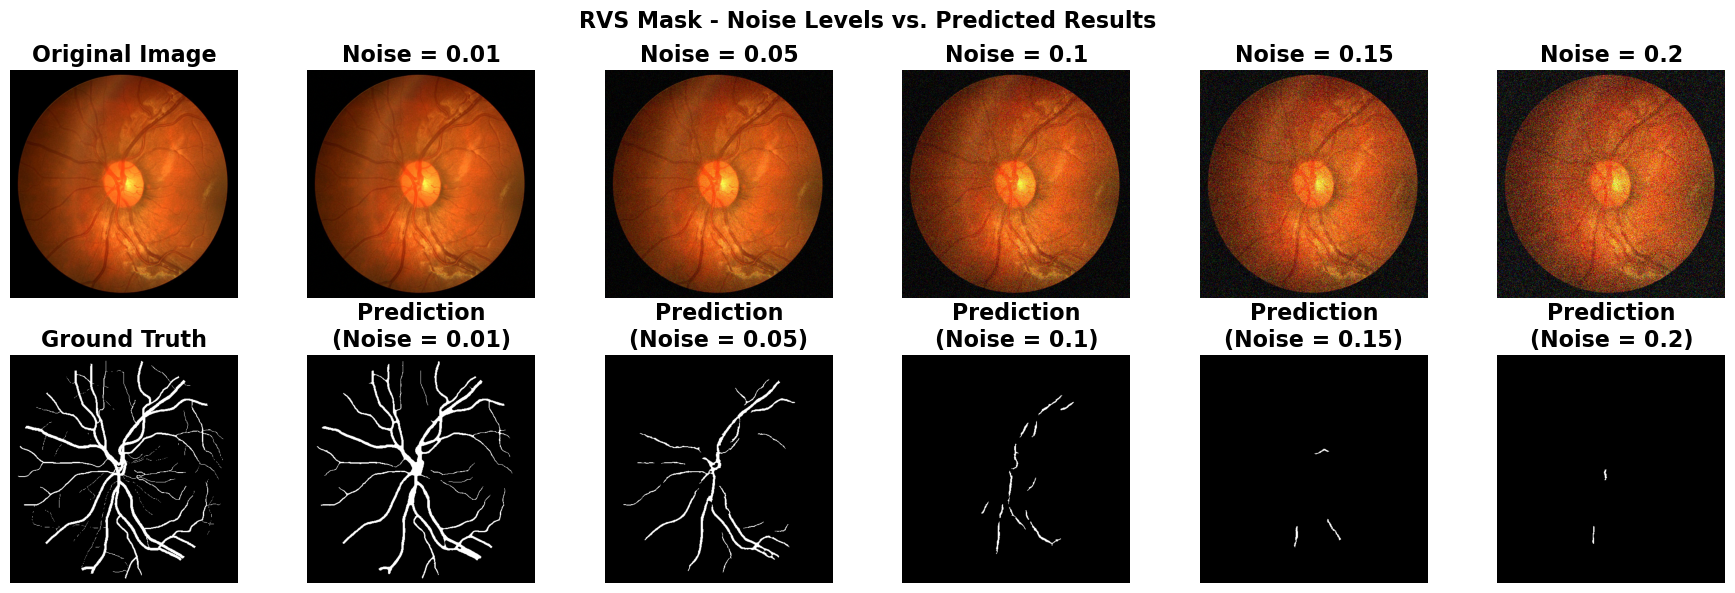


SUMMARY METRICS ACROSS NOISE LEVELS
Noise    Mask   Dice     Jaccard  Sensitivity  Precision  Specificity  Accuracy  
----------------------------------------------------------------------------------------------------
0.01     RVS    0.904    0.824    0.870        0.940      0.995        0.985     
0.05     RVS    0.545    0.375    0.382        0.953      0.998        0.949     
0.1      RVS    0.178    0.098    0.098        0.945      1.000        0.927     
0.15     RVS    0.039    0.020    0.020        0.907      1.000        0.921     
0.2      RVS    0.019    0.010    0.010        0.995      1.000        0.920     


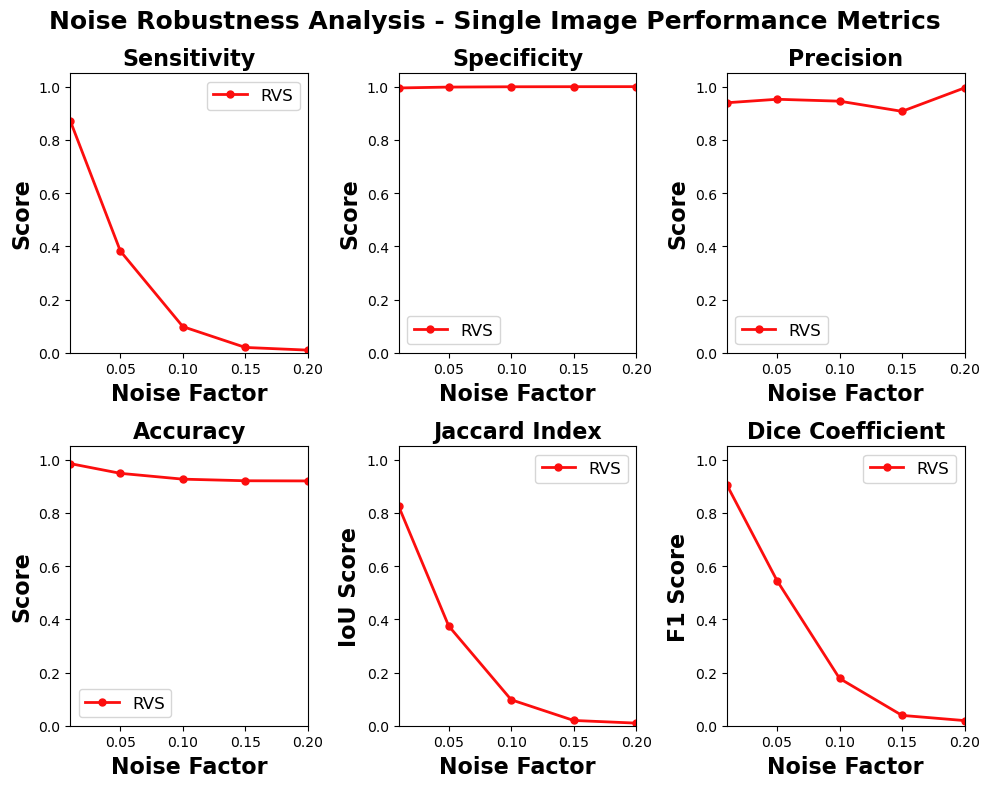

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

def add_noise(data, noise_factor=0.2):
    noise = np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    noisy_data = data + noise_factor * noise
    noisy_data = np.clip(noisy_data, 0.0, 1.0)
    return noisy_data

def getPrediction(img_path, model, noise_factor):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.resize(img, (512, 512))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb.astype(float) / 255.0
    noisy_img_normalized = add_noise(img_normalized, noise_factor=noise_factor)
    noisy_img = (noisy_img_normalized * 255).astype(np.uint8)
    noisy_img = np.expand_dims(noisy_img, 0)[:, :, :, 0:3]
    rvs = model.predict(noisy_img)
    return noisy_img_normalized, rvs

def calculate_metrics(y_true, y_pred):
    # Flatten and ensure binary (0/1) values
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)
    
    # Handle case where there might be no positive samples
    if np.sum(y_true) == 0 and np.sum(y_pred) == 0:
        return {metric: 1.0 for metric in ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']}
    elif np.sum(y_true) == 0:
        return {'SEN': 0.0, 'SPC': 1.0, 'PRE': 0.0, 'ACC': np.mean(y_pred == 0), 
                'JAC': 0.0, 'DICE': 0.0}
    
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Small epsilon to prevent division by zero
    eps = np.finfo(float).eps
    
    # Calculate metrics with numerical stability
    sen = tp / (tp + fn + eps)
    spc = tn / (tn + fp + eps)
    pre = tp / (tp + fp + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    jac = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    
    return {
        'SEN': sen,        # Sensitivity/Recall
        'SPC': spc,        # Specificity
        'PRE': pre,        # Precision
        'ACC': acc,        # Accuracy
        'JAC': jac,        # Jaccard Index (IoU)
        'DICE': dice       # Dice Coefficient
    }

def postprocess_mask(pred_mask, threshold=0.5, min_size=50):
    binary_mask = (pred_mask > threshold).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, 4)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] < min_size:
            binary_mask[labels == i] = 0
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, 
                                 cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))
    return binary_mask

def load_gt_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, (512, 512))
    _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
    return mask

# Configuration - Single image paths
image_path = r"E:\ASI\CHASE DB1\Chase\Images\Image_02L.jpg"
rvs_mask_path = r"E:\ASI\CHASE DB1\Chase\GT1\Image_02L_1stHO.png"
model_path = r"E:\ASI\ASI_Retinal_ChaseGT1.h5"
noise_levels = [0.01, 0.05, 0.1, 0.15, 0.20]
mask_types = ['RVS']

# Load model
print("Loading model...")
model = load_model(model_path, compile= False)
print("Model loaded successfully!")

# Load original image and ground truth masks
print("Loading original image and ground truth masks...")
original_img = cv2.imread(image_path)
original_img = cv2.resize(original_img, (512, 512))
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

rvs_mask = load_gt_mask(rvs_mask_path)

gt_masks = {'RVS': rvs_mask}

# Store results for each noise level
results = {}
predicted_masks = {}
noisy_images = {}

print("Processing noise levels...")
for noise in noise_levels:
    print(f"Processing noise level: {noise}")
    
    # Get prediction and noisy image
    noisy_img_normalized, rvs_pred = getPrediction(image_path, model, noise)
    
    # Store noisy image
    noisy_images[noise] = (noisy_img_normalized * 255).astype(np.uint8)
    
    # Postprocess predictions
    pred_masks = {
        'RVS': postprocess_mask(rvs_pred[0,:,:,0])
    }
    
    predicted_masks[noise] = pred_masks
    
    # Calculate metrics
    metrics_dict = {}
    for mask_type in mask_types:
        metrics_dict[mask_type] = calculate_metrics(gt_masks[mask_type], pred_masks[mask_type])
    
    results[noise] = metrics_dict
    print(f"Completed noise level {noise}")

avg_results = results

def create_mask_comparison_visualizations(original_img, gt_masks, predicted_masks, noisy_images, noise_levels):
    for mask_type in mask_types:
        n_cols = len(noise_levels) + 1  # Original/GT + each noise level
        fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))
        fig.suptitle(f'{mask_type} Mask - Noise Levels vs. Predicted Results', fontsize=16, fontweight='bold')
        
        # --- ROW 1: INPUT IMAGES ---
        # 1. Clean original image
        axes[0, 0].imshow(original_img)
        axes[0, 0].set_title('Original Image', fontsize=16, fontweight='bold')
        axes[0, 0].axis('off')
        
        # 2. Noisy images for each noise factor
        for idx, noise in enumerate(noise_levels, start=1):
            axes[0, idx].imshow(noisy_images[noise])
            axes[0, idx].set_title(f'Noise = {noise}', fontsize=16, fontweight='bold')
            axes[0, idx].axis('off')
            
        # --- ROW 2: MASKS & PREDICTIONS ---
        # 1. Ground truth mask
        axes[1, 0].imshow(gt_masks[mask_type], cmap='gray')
        axes[1, 0].set_title(f'Ground Truth', fontsize=16, fontweight='bold')
        axes[1, 0].axis('off')
        
        # 2. Predicted masks corresponding to each noise level
        for idx, noise in enumerate(noise_levels, start=1):
            mask = predicted_masks[noise][mask_type]
            axes[1, idx].imshow(mask, cmap='gray')
            axes[1, idx].set_title(f'Prediction\n(Noise = {noise})', fontsize=16, fontweight='bold')
            axes[1, idx].axis('off')
            
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)
        plt.show()

# Generate all visualizations
print("\nGenerating visualizations...")

# 3. Mask-type comparison across noise levels
create_mask_comparison_visualizations(original_img_rgb, gt_masks, predicted_masks, noisy_images, noise_levels)

# Print summary metrics table
print("\n" + "="*100)
print("SUMMARY METRICS ACROSS NOISE LEVELS")
print("="*100)

headers = ["Noise", "Mask", "Dice", "Jaccard", "Sensitivity", "Precision", "Specificity", "Accuracy"]
print(f"{headers[0]:<8} {headers[1]:<6} {headers[2]:<8} {headers[3]:<8} {headers[4]:<12} {headers[5]:<10} {headers[6]:<12} {headers[7]:<10}")
print("-" * 100)

for noise in noise_levels:
    for i, mask_type in enumerate(mask_types):
        metrics = results[noise][mask_type]
        if i == 0:
            noise_str = f"{noise:<8}"
        else:
            noise_str = " " * 8
            
        print(f"{noise_str} {mask_type:<6} {metrics['DICE']:<8.3f} {metrics['JAC']:<8.3f} "
              f"{metrics['SEN']:<12.3f} {metrics['PRE']:<10.3f} {metrics['SPC']:<12.3f} {metrics['ACC']:<10.3f}")

# Enhanced plotting function with better visualization
def plot_enhanced_metrics(avg_results, noise_levels, mask_types):
    # Create a more comprehensive visualization
    fig = plt.figure(figsize=(10, 8))
    
    # Define colors and markers
    colors = {'RVS': "#FC0E0E"}
    markers = {'RVS': 'o'}
    line_styles = {'RVS': '-'}
    
    metrics = ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']
    metric_names = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Jaccard Index', 'Dice Coefficient']
    metric_ylabels = ['Score', 'Score', 'Score', 'Score', 'IoU Score', 'F1 Score']
    
    # Plot 1: Individual metric plots
    for i, (metric, name, ylabel) in enumerate(zip(metrics, metric_names, metric_ylabels), 1):
        ax = plt.subplot(2, 3, i)
        
        for mask_type in mask_types:
            values = [avg_results[noise][mask_type][metric] for noise in noise_levels]
            
            # Plot the main line
            ax.plot(noise_levels, values, 
                   color=colors[mask_type], marker=markers[mask_type], 
                   label=mask_type, linewidth=2, markersize=5, 
                   linestyle=line_styles[mask_type])
        
        ax.set_xlabel('Noise Factor', fontsize=16, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
        ax.set_title(f'{name}', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(min(noise_levels), max(noise_levels))
    
    plt.suptitle('Noise Robustness Analysis - Single Image Performance Metrics', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

plot_enhanced_metrics(avg_results, noise_levels, mask_types)

Noise Overall Image

Scanning for image files...
Found 6 image-ground truth pairs
Loading model...
Model loaded successfully!
Processing all images...

Processing image 1/6: Image_02L.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
Completed Image_02L.jpg

Processing image 2/6: Image_02R.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
Completed Image_02R.jpg

Processing image 3/6: Image_13R.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
Completed Image_13R.jpg

Processing image 4/6: Image_02L.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2

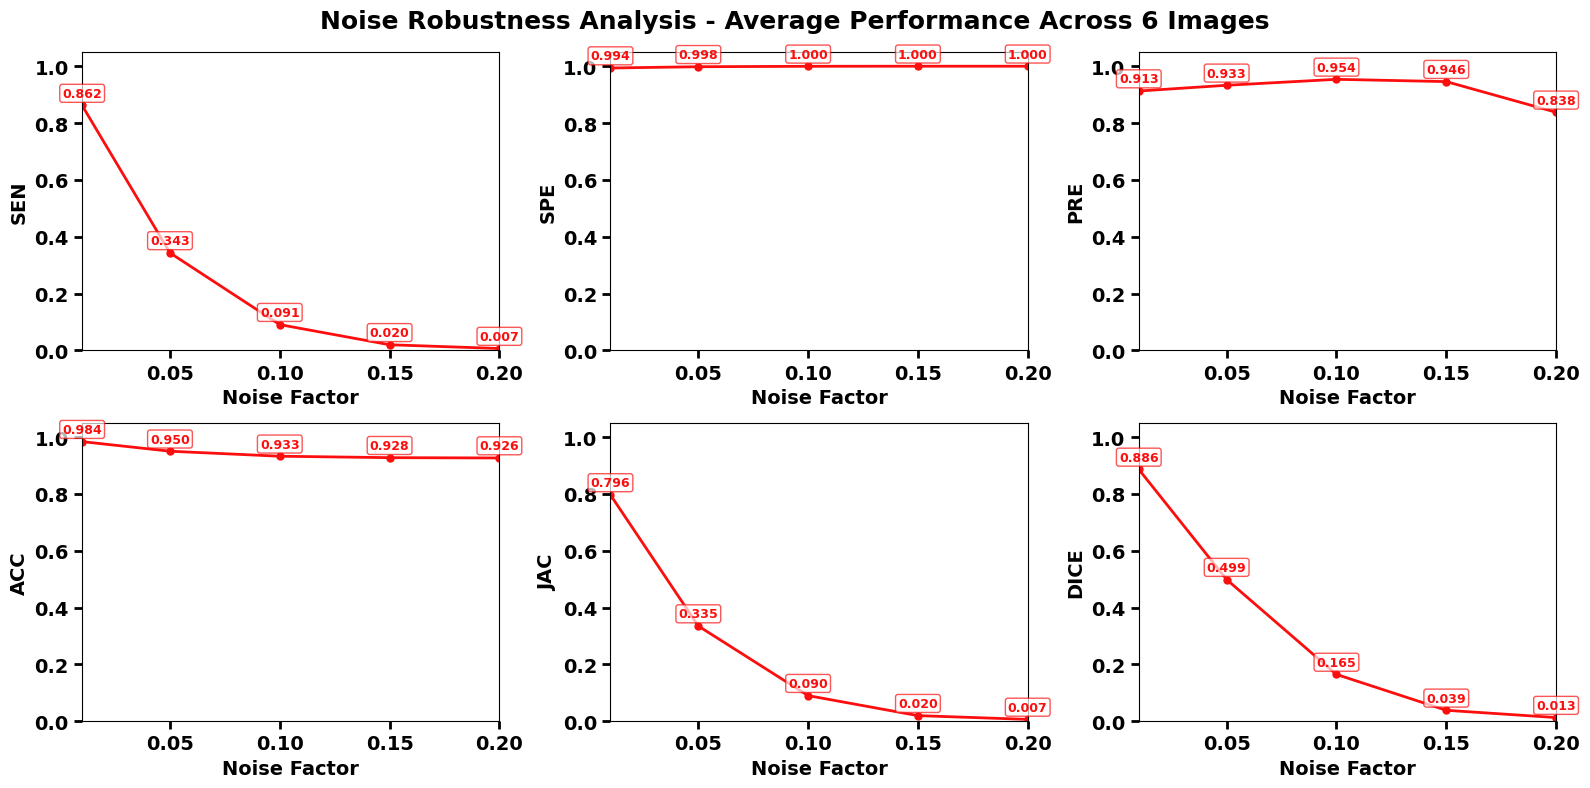


PROCESSING SUMMARY
Total images processed: 6
Noise levels tested: [0.01, 0.05, 0.1, 0.15, 0.2]
Metrics calculated: Dice, Jaccard, Sensitivity, Precision, Specificity, Accuracy
Results saved to segmentation_results_20260810_132519.txt


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import os
from glob import glob

def add_noise(data, noise_factor=0.2):
    noise = np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    noisy_data = data + noise_factor * noise
    noisy_data = np.clip(noisy_data, 0.0, 1.0)
    return noisy_data

def getPrediction(img_path, model, noise_factor):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.resize(img, (512, 512))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_normalized = img_rgb.astype(float) / 255.0
    noisy_img_normalized = add_noise(img_normalized, noise_factor=noise_factor)
    noisy_img = (noisy_img_normalized * 255).astype(np.uint8)
    noisy_img = np.expand_dims(noisy_img, 0)[:, :, :, 0:3]
    rvs = model.predict(noisy_img)
    return noisy_img_normalized, rvs

def calculate_metrics(y_true, y_pred):
    # Flatten and ensure binary (0/1) values
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)
    
    # Handle case where there might be no positive samples
    if np.sum(y_true) == 0 and np.sum(y_pred) == 0:
        return {metric: 1.0 for metric in ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']}
    elif np.sum(y_true) == 0:
        return {'SEN': 0.0, 'SPC': 1.0, 'PRE': 0.0, 'ACC': np.mean(y_pred == 0), 
                'JAC': 0.0, 'DICE': 0.0}
    
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Small epsilon to prevent division by zero
    eps = np.finfo(float).eps
    
    # Calculate metrics with numerical stability
    sen = tp / (tp + fn + eps)
    spc = tn / (tn + fp + eps)
    pre = tp / (tp + fp + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)
    jac = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    
    return {
        'SEN': sen,        # Sensitivity/Recall
        'SPC': spc,        # Specificity
        'PRE': pre,        # Precision
        'ACC': acc,        # Accuracy
        'JAC': jac,        # Jaccard Index (IoU)
        'DICE': dice       # Dice Coefficient
    }

def postprocess_mask(pred_mask, threshold=0.5, min_size=50):
    binary_mask = (pred_mask > threshold).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, 4)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] < min_size:
            binary_mask[labels == i] = 0
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, 
                                 cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))
    return binary_mask

def load_gt_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, (512, 512))
    _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
    return mask

def get_image_files(image_dir, gt_dir):
    """Get all image files from directories and verify ground truth exists"""
    image_files = []
    supported_formats = ['*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff', '*.bmp']
   
    for format in supported_formats:
        image_files.extend(glob(os.path.join(image_dir, format)))
        image_files.extend(glob(os.path.join(image_dir, format.upper())))
   
    valid_pairs = []
    for img_path in image_files:
        filename = os.path.basename(img_path)
        base_name = os.path.splitext(filename)[0]
        mask_name = f"{base_name}_1stHO.png"
        gt_path = os.path.join(gt_dir, mask_name)
       
        if os.path.exists(gt_path):
            valid_pairs.append((img_path, gt_path, filename))
        else:
            print(f"Warning: Ground truth not found for {filename}")
   
    return valid_pairs

# Configuration - Directory paths
image_dir = r"E:\ASI\CHASE DB1\Chase\Test\Images"
gt_dir = r"E:\ASI\CHASE DB1\Chase\Test\GT1"
model_path = r"E:\ASI\ASI_Retinal_ChaseGT1.h5"
noise_levels = [0.01, 0.05, 0.1, 0.15, 0.20]
mask_types = ['RVS']

# Get all image files
print("Scanning for image files...")
image_pairs = get_image_files(image_dir, gt_dir)

if not image_pairs:
    print("No valid image pairs found. Check your directories.")
    exit()

print(f"Found {len(image_pairs)} image-ground truth pairs")

# Load model
print("Loading model...")
model = load_model(model_path, compile=False)
print("Model loaded successfully!")

# Store overall results
overall_results = {noise: {mask_type: [] for mask_type in mask_types} for noise in noise_levels}
individual_results = {}

print("Processing all images...")
for img_idx, (image_path, gt_path, filename) in enumerate(image_pairs, 1):
    print(f"\nProcessing image {img_idx}/{len(image_pairs)}: {filename}")
    
    # Load ground truth mask
    try:
        rvs_mask = load_gt_mask(gt_path)
        gt_masks = {'RVS': rvs_mask}
    except Exception as e:
        print(f"Error loading ground truth for {filename}: {e}")
        continue
    
    # Store results for current image
    image_results = {}
    
    for noise in noise_levels:
        try:
            # Get prediction and noisy image
            noisy_img_normalized, rvs_pred = getPrediction(image_path, model, noise)
            
            # Postprocess predictions
            pred_masks = {
                'RVS': postprocess_mask(rvs_pred[0,:,:,0])
            }
            
            # Calculate metrics
            metrics_dict = {}
            for mask_type in mask_types:
                metrics = calculate_metrics(gt_masks[mask_type], pred_masks[mask_type])
                metrics_dict[mask_type] = metrics
                overall_results[noise][mask_type].append(metrics)
            
            image_results[noise] = metrics_dict
            
        except Exception as e:
            print(f"Error processing {filename} at noise level {noise}: {e}")
            continue
    
    individual_results[filename] = image_results
    print(f"Completed {filename}")

# Calculate average results across all images
print("\nCalculating average results...")
avg_results = {}
for noise in noise_levels:
    avg_results[noise] = {}
    for mask_type in mask_types:
        if overall_results[noise][mask_type]:
            avg_metrics = {}
            for metric in ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']:
                values = [result[metric] for result in overall_results[noise][mask_type]]
                avg_metrics[metric] = np.mean(values)
            avg_results[noise][mask_type] = avg_metrics

# Print individual image results
print("\n" + "="*120)
print("INDIVIDUAL IMAGE RESULTS")
print("="*120)

for filename, results in individual_results.items():
    print(f"\n{filename}:")
    headers = ["Noise", "Dice", "Jaccard", "Sensitivity", "Precision", "Specificity", "Accuracy"]
    print(f"{headers[0]:<8} {headers[1]:<8} {headers[2]:<8} {headers[3]:<12} {headers[4]:<10} {headers[5]:<12} {headers[6]:<10}")
    print("-" * 80)
    
    for noise in noise_levels:
        if noise in results:
            metrics = results[noise]['RVS']
            print(f"{noise:<8} {metrics['DICE']:<8.3f} {metrics['JAC']:<8.3f} "
                  f"{metrics['SEN']:<12.3f} {metrics['PRE']:<10.3f} {metrics['SPC']:<12.3f} {metrics['ACC']:<10.3f}")

# Print summary metrics table (averages)
print("\n" + "="*120)
print("SUMMARY METRICS ACROSS ALL IMAGES (AVERAGES)")
print("="*120)

headers = ["Noise", "Mask", "Dice", "Jaccard", "Sensitivity", "Precision", "Specificity", "Accuracy"]
print(f"{headers[0]:<8} {headers[1]:<6} {headers[2]:<8} {headers[3]:<8} {headers[4]:<12} {headers[5]:<10} {headers[6]:<12} {headers[7]:<10}")
print("-" * 120)

for noise in noise_levels:
    for i, mask_type in enumerate(mask_types):
        metrics = avg_results[noise][mask_type]
        if i == 0:
            noise_str = f"{noise:<8}"
        else:
            noise_str = " " * 8
            
        print(f"{noise_str} {mask_type:<6} {metrics['DICE']:<8.3f} {metrics['JAC']:<8.3f} "
              f"{metrics['SEN']:<12.3f} {metrics['PRE']:<10.3f} {metrics['SPC']:<12.3f} {metrics['ACC']:<10.3f}")

# Enhanced plotting function with value annotations
def plot_enhanced_metrics(avg_results, noise_levels, mask_types):
    # Create a more comprehensive visualization
    fig = plt.figure(figsize=(16, 8))
    
    # Define colors and markers
    colors = {'RVS': "#FC0E0E"}
    
    metrics = ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']
    metric_names = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Jaccard Index', 'Dice Coefficient']
    metric_ylabels = ['SEN', 'SPE', 'PRE', 'ACC', 'JAC', 'DICE']
    
    # Plot 1: Individual metric plots
    for i, (metric, name, ylabel) in enumerate(zip(metrics, metric_names, metric_ylabels), 1):
        ax = plt.subplot(2, 3, i)
        
        for mask_type in mask_types:
            values = [avg_results[noise][mask_type][metric] for noise in noise_levels]
            
            # Plot the main line
            line = ax.plot(noise_levels, values, 
                          color=colors[mask_type], marker='o', 
                          linewidth=2, markersize=5)
            
            # Add value annotations on each point
            for j, (x, y) in enumerate(zip(noise_levels, values)):
                # Position the text slightly above the point
                vertical_offset = 0.02
                ax.annotate(f'{y:.3f}', 
                           xy=(x, y), 
                           xytext=(x, y + vertical_offset),
                           ha='center', va='bottom',
                           fontsize=9, fontweight='bold',
                           color=colors[mask_type],
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='white', 
                                   edgecolor=colors[mask_type], alpha=0.7))
        
        # Set bold x-ticks and y-ticks for each subplot
        ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=14, width=2, length=6)
        
        # Make tick labels bold
        for tick in ax.xaxis.get_major_ticks():
            tick.label1.set_fontweight('bold')
        for tick in ax.yaxis.get_major_ticks():
            tick.label1.set_fontweight('bold')
        
        ax.set_xlabel('Noise Factor', fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_xlim(min(noise_levels), max(noise_levels))

    plt.suptitle(f'Noise Robustness Analysis - Average Performance Across {len(image_pairs)} Images', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Alternative plotting function with different annotation style
def plot_metrics_with_values(avg_results, noise_levels, mask_types):
    """Alternative plotting function with values inside the markers"""
    fig = plt.figure(figsize=(16, 8))
    
    colors = {'RVS': "#FC0E0E"}
    
    metrics = ['SEN', 'SPC', 'PRE', 'ACC', 'JAC', 'DICE']
    metric_names = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Jaccard Index', 'Dice Coefficient']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names), 1):
        ax = plt.subplot(2, 3, i)
        
        for mask_type in mask_types:
            values = [avg_results[noise][mask_type][metric] for noise in noise_levels]
            
            # Plot with larger markers
            line = ax.plot(noise_levels, values, 
                          color=colors[mask_type], marker='o', 
                          linewidth=2, markersize=8)
            
            # Add values inside or near markers
            for j, (x, y) in enumerate(zip(noise_levels, values)):
                # For values > 0.8, put text inside marker, otherwise above
                if y > 0.8:
                    text_color = 'white'
                    va = 'center'
                    ha = 'center'
                    offset = 0
                else:
                    text_color = colors[mask_type]
                    va = 'bottom'
                    ha = 'center'
                    offset = 0.03
                
                ax.annotate(f'{y:.3f}', 
                           xy=(x, y), 
                           xytext=(x, y + offset),
                           ha=ha, va=va,
                           fontsize=8, fontweight='bold',
                           color=text_color)
        
        ax.tick_params(axis='both', which='major', labelsize=12, width=2)
        for tick in ax.xaxis.get_major_ticks():
            tick.label1.set_fontweight('bold')
        for tick in ax.yaxis.get_major_ticks():
            tick.label1.set_fontweight('bold')
        
        ax.set_xlabel('Noise Factor', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Noise Robustness Analysis with Value Annotations', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Generate overall visualization
print("\nGenerating overall visualization...")
plot_enhanced_metrics(avg_results, noise_levels, mask_types)

# Uncomment the line below to try the alternative plotting style
# plot_metrics_with_values(avg_results, noise_levels, mask_types)

# Print final statistics
print("\n" + "="*80)
print("PROCESSING SUMMARY")
print("="*80)
print(f"Total images processed: {len(image_pairs)}")
print(f"Noise levels tested: {noise_levels}")
print(f"Metrics calculated: Dice, Jaccard, Sensitivity, Precision, Specificity, Accuracy")

import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"segmentation_results_{timestamp}.txt"

with open(filename, 'w') as f:
    f.write("Retinal Vessel Segmentation Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Images processed: {len(image_pairs)}\n")
    f.write(f"Noise levels: {noise_levels}\n\n")
    
    f.write("Average Results:\n")
    f.write("-" * 80 + "\n")
    for noise in noise_levels:
        f.write(f"Noise Level: {noise}\n")
        for mask_type in mask_types:
            metrics = avg_results[noise][mask_type]
            f.write(f"  {mask_type}: Dice={metrics['DICE']:.3f}, Jaccard={metrics['JAC']:.3f}, "
                   f"Sensitivity={metrics['SEN']:.3f}, Precision={metrics['PRE']:.3f}, "
                   f"Specificity={metrics['SPC']:.3f}, Accuracy={metrics['ACC']:.3f}\n")

print(f"Results saved to {filename}")

Radial Image Analysis

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   

COMPREHENSIVE VISUAL ANALYSIS FOR: RVS

Radial Profile Differences for RVS:
Metric          Value          
------------------------------
Highest Diff    0.272727
Lowest Diff     0.000000
Average Diff    0.005343


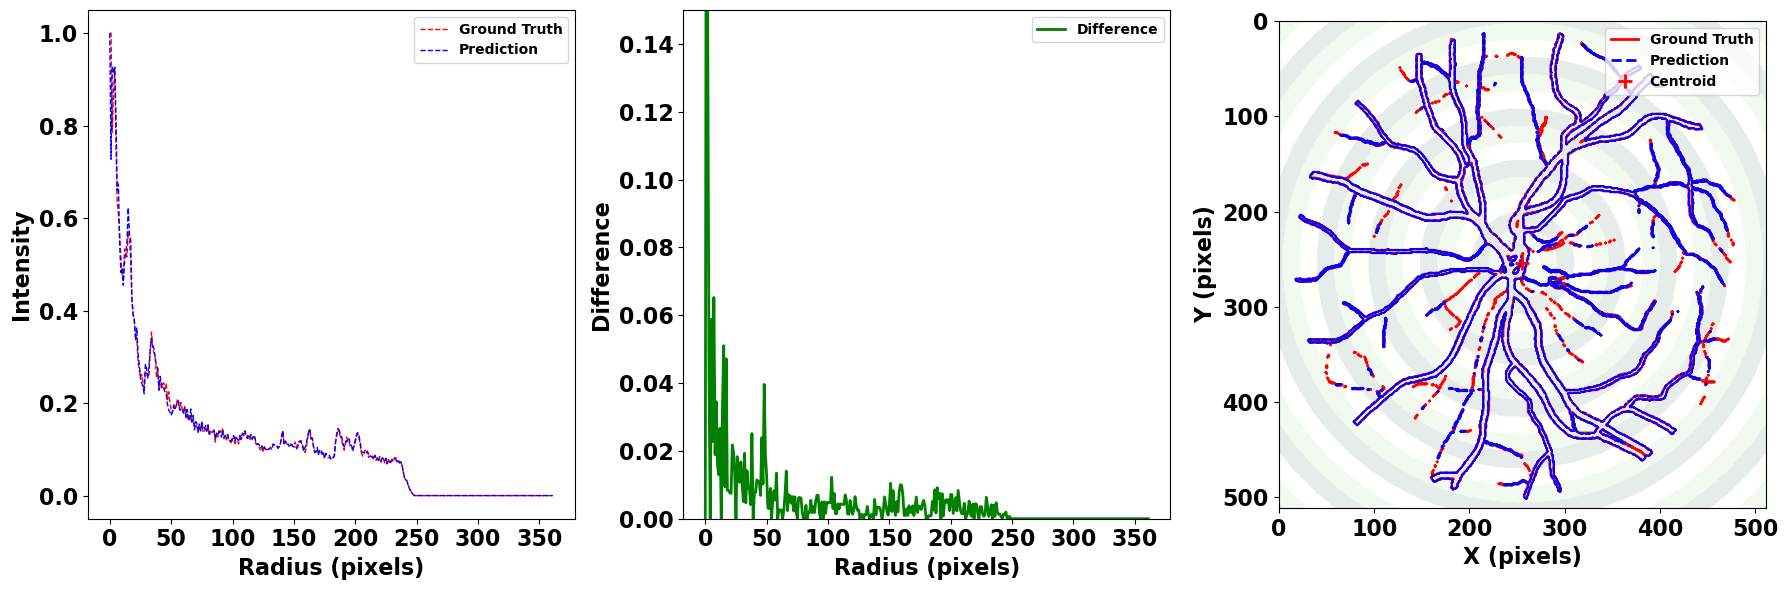

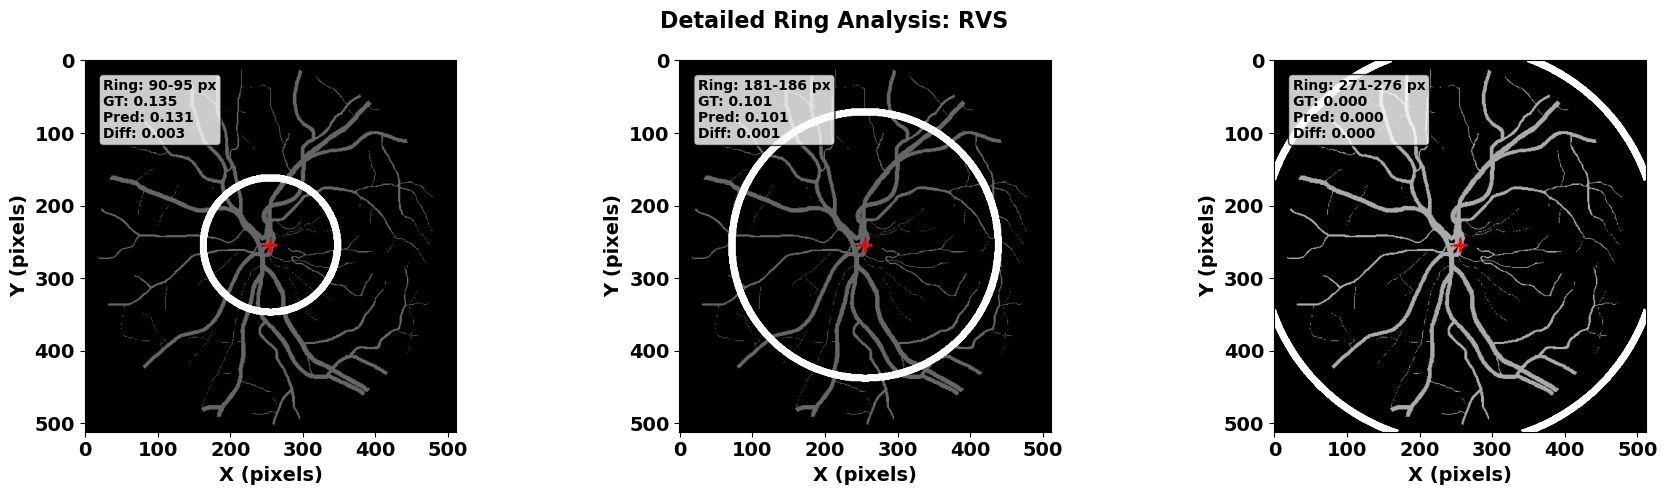

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage.measure import regionprops
from tensorflow.keras.models import load_model

# Load model
model_path = r"E:\ASI\ASI_Retinal_ChaseGT1.h5"
model = load_model(model_path, compile=False)

def getPrediction(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, 0)[:,:,:,0:3]
    mask = model.predict(img)
    return mask

# Load and prepare images
image_path = r"E:\ASI\CHASE DB1\Chase\Images\Image_02L.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (512, 512))

# Load ground truth masks
rvs_mask_path = r"E:\ASI\CHASE DB1\Chase\GT1\Image_02L_1stHO.png"
rvs_mask = cv2.imread(rvs_mask_path, cv2.IMREAD_GRAYSCALE)
rvs_mask = cv2.resize(rvs_mask, (512, 512))
_, rvs_mask = cv2.threshold(rvs_mask, 127, 1, cv2.THRESH_BINARY)

# Get predictions and probability maps
rvs = getPrediction(image_path, model)
rvs_prob = rvs[0,:,:,0]

# Binary predictions
rvs_pred = (rvs_prob > 0.1).astype(np.uint8)

def plot_radial_profile_with_rings(true_mask, pred_mask, title):
    """
    Enhanced radial profile analysis that also visualizes the concentric rings
    """
    # Find centroid
    props = regionprops(true_mask.astype(int))[0]
    centroid = props.centroid
    
    # Create polar coordinates
    y, x = np.indices(true_mask.shape)
    y = y - centroid[0]
    x = x - centroid[1]
    r = np.sqrt(x**2 + y**2)
    
    # Calculate radial profiles
    r_max = int(np.max(r))
    true_radial = np.zeros(r_max)
    pred_radial = np.zeros(r_max)
    
    # Create visualization of rings
    ring_visualization = np.zeros_like(true_mask, dtype=float)
    
    for radius in range(r_max):
        mask_ring = (r >= radius) & (r < radius + 1)
        true_radial[radius] = np.mean(true_mask[mask_ring])
        pred_radial[radius] = np.mean(pred_mask[mask_ring])
        
        # Store ring information for visualization (alternating colors)
        ring_visualization[mask_ring] = (radius % 2) * 0.5 + 0.3
    
    # Calculate differences
    diff = np.abs(true_radial - pred_radial)
    
    print(f"\nRadial Profile Differences for {title}:")
    print(f"{'Metric':<15} {'Value':<15}")
    print("-" * 30)
    print(f"{'Highest Diff':<15} {np.max(diff):.6f}")
    print(f"{'Lowest Diff':<15} {np.min(diff):.6f}")
    print(f"{'Average Diff':<15} {np.mean(diff):.6f}")
    
    # Enhanced plotting with rings visualization
    plt.figure(figsize=(18, 6))
    
    # Subplot 1: Radial profiles
    plt.subplot(1, 3, 1)
    plt.plot(true_radial, 'r--', label='Ground Truth', linewidth=1)
    plt.plot(pred_radial, 'b--', label='Prediction', linewidth=1)
    plt.xlabel('Radius (pixels)', fontsize=16, fontweight='bold')
    plt.ylabel('Intensity', fontsize=16, fontweight='bold')
    #plt.title(f'Radial Profile: {title}', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=16, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.legend(fontsize=16, prop={'weight': 'bold'})

    
    # Subplot 2: Differences
    plt.subplot(1, 3, 2)
    plt.plot(diff, 'g-', linewidth=2)
    plt.xlabel('Radius (pixels)', fontsize=16, fontweight='bold')
    plt.ylabel('Difference', fontsize=16, fontweight='bold')
    plt.ylim(0, 0.15)
    #plt.title('Radial Profile Differences', fontsize=16, fontweight='bold')
    plt.xticks(fontsize=16, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.legend(['Difference'], fontsize=16, prop={'weight': 'bold'})
    
    # Subplot 3: Rings visualization
    plt.subplot(1, 3, 3)
    
    # Create a more detailed ring visualization with selected rings
    detailed_rings = np.zeros_like(true_mask, dtype=float)
    
    # Show every 10th ring for clarity
    ring_step = max(1, r_max // 20)  # Show about 20 rings or adjust based on size
    ring_indices = range(0, r_max, ring_step)
    
    for i, radius in enumerate(ring_indices):
        mask_ring = (r >= radius) & (r < radius + ring_step)
        detailed_rings[mask_ring] = (i % 3) * 0.3 + 0.2
    
    # Overlay the original mask on top of rings
    overlay = detailed_rings.copy()
    overlay[true_mask > 0] = 0.8  # Highlight true mask regions
    
    # Subplot 3: Rings visualization
    plt.subplot(1, 3, 3)
    plt.imshow(overlay, cmap='YlGn', alpha=0.1)
    plt.contour(true_mask, colors='red', linewidths=1, linestyles='solid', alpha=0.8)  # Removed label
    plt.contour(pred_mask, colors='blue', linewidths=1, linestyles='dashed', alpha=0.8)  # Removed label
    plt.plot(centroid[1], centroid[0], 'r+', markersize=10, markeredgewidth=2, label='Centroid')
    
    # Create proxy artists for legend
    legend_elements = [
        Line2D([0], [0], color='red', linestyle='solid', linewidth=2, label='Ground Truth'),
        Line2D([0], [0], color='blue', linestyle='dashed', linewidth=2, label='Prediction'),
        Line2D([0], [0], color='red', marker='+', linestyle='None', markersize=10, markeredgewidth=2, label='Centroid')
    ]
    plt.xlabel('X (pixels)', fontsize=16, fontweight='bold')
    plt.ylabel('Y (pixels)', fontsize=16, fontweight='bold')
    #plt.title(f'Concentric Rings: {title}', fontsize=16, fontweight='bold')
    plt.legend(handles=legend_elements, fontsize=16, prop={'weight': 'bold'})
    plt.xticks(fontsize=16, fontweight='bold')
    plt.yticks(fontsize=16, fontweight='bold')
    plt.tight_layout()

def plot_detailed_ring_analysis(true_mask, pred_mask, title):
    """
    Detailed visualization showing individual ring extraction
    """
    # Find centroid
    props = regionprops(true_mask.astype(int))[0]
    centroid = props.centroid
    
    # Create polar coordinates
    y, x = np.indices(true_mask.shape)
    y = y - centroid[0]
    x = x - centroid[1]
    r = np.sqrt(x**2 + y**2)
    
    # Select specific rings to visualize
    r_max = int(np.max(r))
    sample_radii = [r_max//4, r_max//2, 3*r_max//4]  # Show rings at 25%, 50%, 75% of max radius
    
    plt.figure(figsize=(18, 5))
    plt.suptitle(f'Detailed Ring Analysis: {title}', fontsize=16, fontweight='bold')
    
    for i, radius in enumerate(sample_radii):
        # Create ring mask
        ring_width = 5  # pixels
        mask_ring = (r >= radius) & (r < radius + ring_width)
        
        # Create visualization
        ring_viz = np.zeros_like(true_mask, dtype=float)
        ring_viz[mask_ring] = 0.6
        ring_viz[true_mask > 0] += 0.4  # Add true mask
        
        plt.subplot(1, 3, i+1)
        plt.imshow(ring_viz, cmap='gray')
        plt.contour(mask_ring.astype(int), colors='white', linewidths=2, alpha=0.8)
        plt.plot(centroid[1], centroid[0], 'r+', markersize=10, markeredgewidth=2)
        
        plt.xlabel('X (pixels)', fontsize=14, fontweight='bold')
        plt.ylabel('Y (pixels)', fontsize=14, fontweight='bold')
        plt.xticks(fontsize=14, fontweight='bold')
        plt.yticks(fontsize=14, fontweight='bold')
        
        # Calculate statistics for this ring
        true_ring_mean = np.mean(true_mask[mask_ring])
        pred_ring_mean = np.mean(pred_mask[mask_ring])
        ring_diff = np.abs(true_ring_mean - pred_ring_mean)
        
        # Add text box with ring statistics + pixel range
        textstr = (f'Ring: {radius}-{radius + ring_width} px\n'
                   f'GT: {true_ring_mean:.3f}\n'
                   f'Pred: {pred_ring_mean:.3f}\n'
                   f'Diff: {ring_diff:.3f}')
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='top', bbox=props, fontweight='bold')
    
    plt.tight_layout()

def comprehensive_visual_analysis(img, true_masks, pred_masks, pred_probs, mask_names):
    """
    Complete visual analysis for all masks with enhanced ring visualization
    """
    for i, (true_mask, pred_mask, pred_prob, name) in enumerate(zip(true_masks, pred_masks, pred_probs, mask_names)):
        print(f"\n{'='*60}")
        print(f"COMPREHENSIVE VISUAL ANALYSIS FOR: {name}")
        print(f"{'='*60}")
        
        # Enhanced radial profile with rings
        plot_radial_profile_with_rings(true_mask, pred_mask, name)
        plt.show()
        
        # Detailed ring analysis
        plot_detailed_ring_analysis(true_mask, pred_mask, name)
        plt.show()

# Usage
mask_names = ['RVS']
true_masks = [rvs_mask]
pred_masks = [rvs_pred]
pred_probs = [rvs_prob]

comprehensive_visual_analysis(img, true_masks, pred_masks, pred_probs, mask_names)